In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error,
    r2_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters for plotting
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 8)

In [20]:
# Fetch dataset
print("Fetching CDC Diabetes Health Indicators dataset...")
cdc_data = fetch_ucirepo(id=891)

# Extract features and targets
X_raw = cdc_data.data.features
y_raw = cdc_data.data.targets

# Merge into a master dataframe
df_master = pd.concat([X_raw, y_raw], axis=1)

# Feature Engineering: Derive Obesity from BMI (BMI >= 30 is the clinical threshold)
df_master['Obesity'] = (df_master['BMI'] >= 30).astype(int)

print(f"Dataset Acquisition Complete: {df_master.shape[0]} records and {df_master.shape[1]} attributes identified.")
df_master.head()

Fetching CDC Diabetes Health Indicators dataset...
Dataset Acquisition Complete: 253680 records and 23 attributes identified.


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary,Obesity
0,1,1,1,40,1,0,0,0,0,1,...,5,18,15,1,0,9,4,3,0,1
1,0,0,0,25,1,0,0,1,0,0,...,3,0,0,0,0,7,6,1,0,0
2,1,1,1,28,0,0,0,0,1,0,...,5,30,30,1,0,9,4,8,0,0
3,1,0,1,27,0,0,0,1,1,1,...,2,0,0,0,0,11,3,6,0,0
4,1,1,1,24,0,0,0,1,1,1,...,2,3,0,0,0,11,5,4,0,0


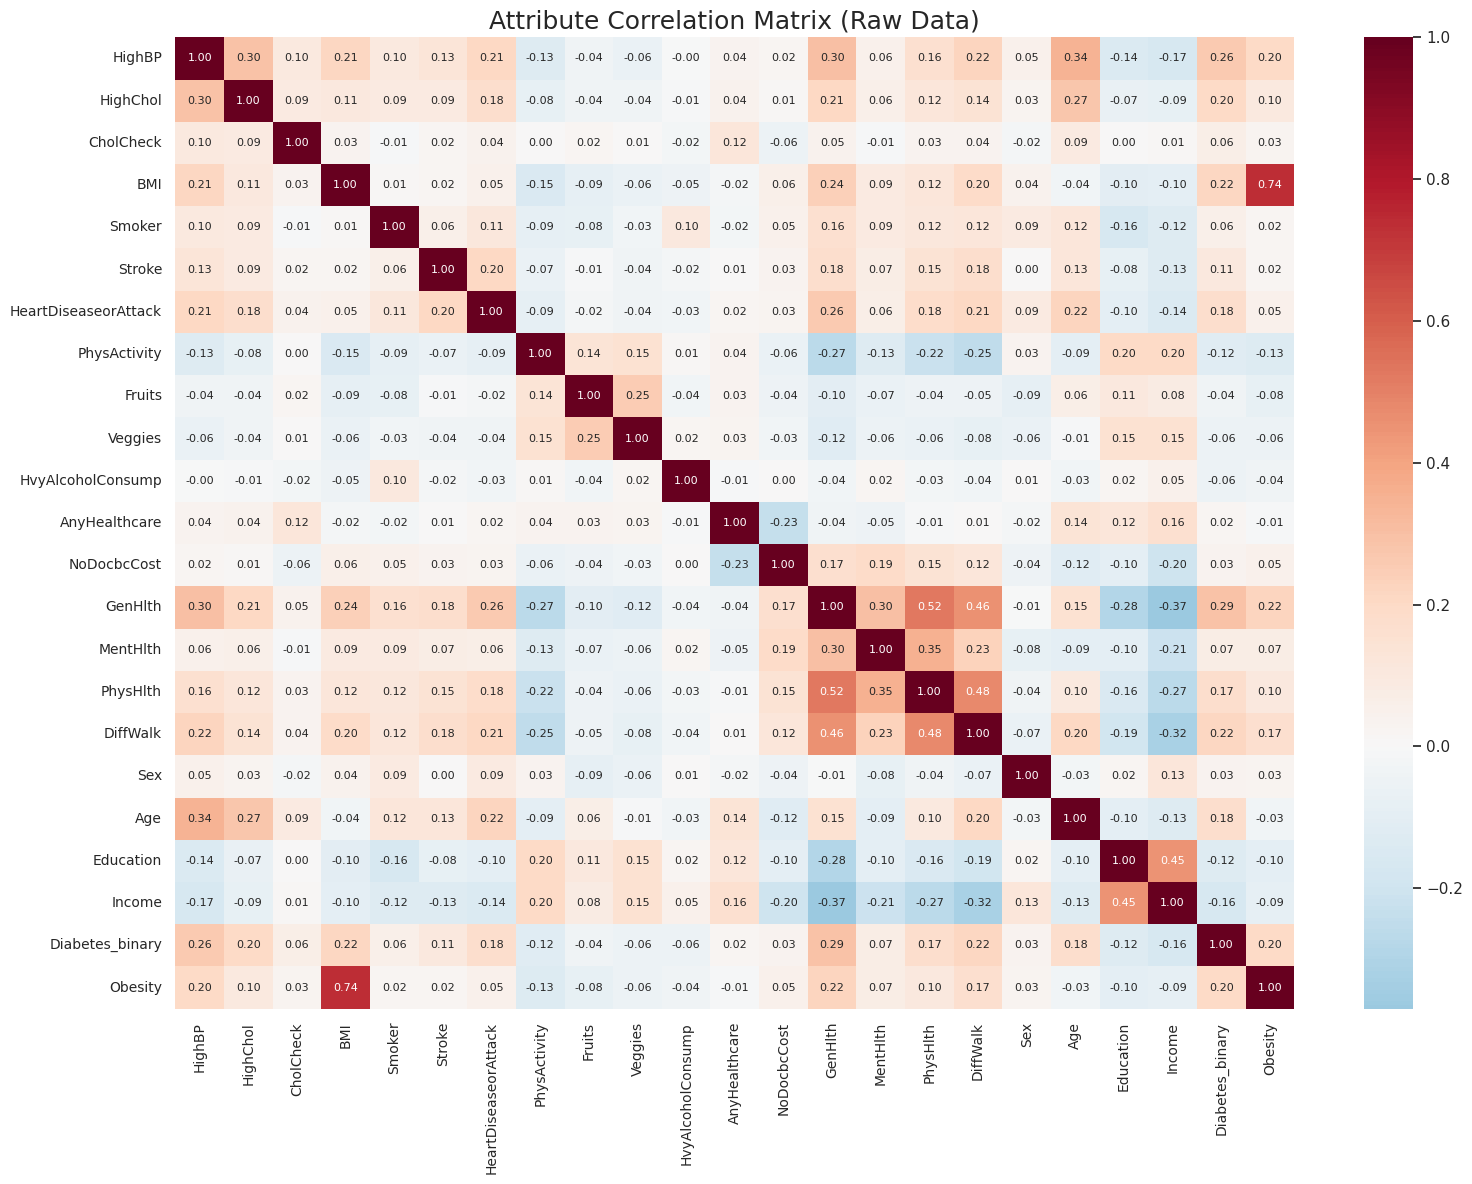

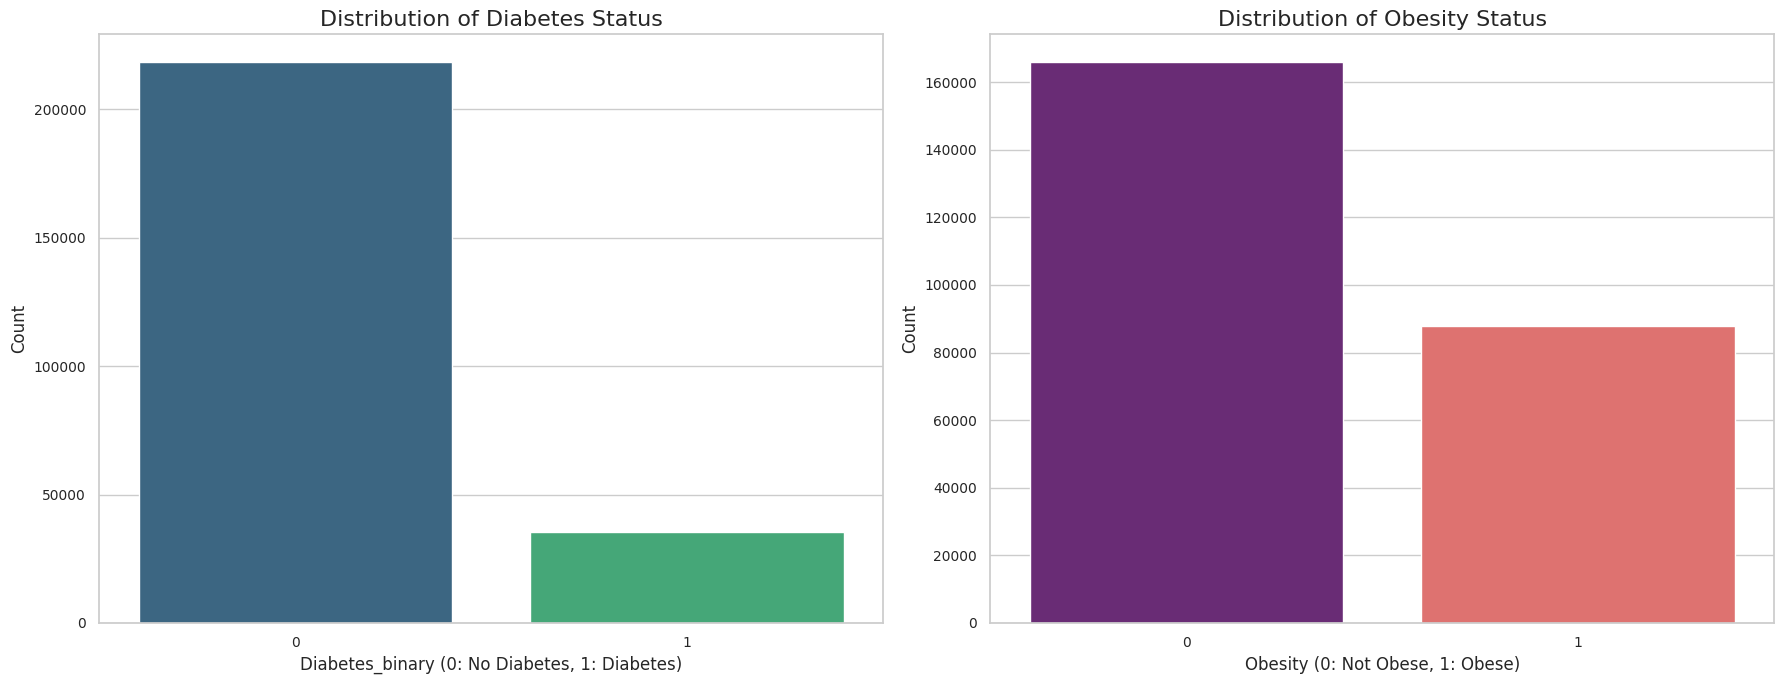

In [21]:
# 3.1 Correlation Heatmap (Raw Data)
plt.figure(figsize=(16, 12))
sns.heatmap(df_master.corr(), annot=True, fmt=".2f", cmap='RdBu_r', center=0, annot_kws={"size": 8})
plt.title('Attribute Correlation Matrix (Raw Data)', fontsize=18)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

# 3.2 Target Variable Distribution
fig, ax = plt.subplots(1, 2, figsize=(18, 7))
sns.countplot(x='Diabetes_binary', data=df_master, ax=ax[0], palette='viridis')
ax[0].set_title('Distribution of Diabetes Status', fontsize=16)
ax[0].set_xlabel('Diabetes_binary (0: No Diabetes, 1: Diabetes)', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].tick_params(labelsize=10)

sns.countplot(x='Obesity', data=df_master, ax=ax[1], palette='magma')
ax[1].set_title('Distribution of Obesity Status', fontsize=16)
ax[1].set_xlabel('Obesity (0: Not Obese, 1: Obese)', fontsize=12)
ax[1].set_ylabel('Count', fontsize=12)
ax[1].tick_params(labelsize=10)

plt.tight_layout()
plt.show()

In [22]:
# 4.1 Feature Scaling
scaler = StandardScaler()
# Numerical attributes requiring normalization
numerical_cols = ['BMI', 'Age', 'GenHlth', 'MentHlth', 'PhysHlth', 'Education', 'Income']
df_preprocessed = df_master.copy()
df_preprocessed[numerical_cols] = scaler.fit_transform(df_preprocessed[numerical_cols])

# 4.2 Handling Biasness via SMOTE (Synthetic Minority Over-sampling)
# To keep it CPU-friendly while maintaining significance, we use a substantial sample
df_sample = df_preprocessed.sample(n=40000, random_state=42)

X_prep = df_sample.drop(columns=['Diabetes_binary', 'Obesity'])
y_diabetes = df_sample['Diabetes_binary']
y_obesity = df_sample['Obesity']

# Balance Diabetes Target
smote_d = SMOTE(random_state=42)
X_res_d, y_res_d = smote_d.fit_resample(X_prep, y_diabetes)

# Balance Obesity Target (Separately for specific model training)
smote_o = SMOTE(random_state=42)
X_res_o, y_res_o = smote_o.fit_resample(X_prep, y_obesity)

print(f"Preprocessing Complete. Balanced samples generated for both Diabetes and Obesity targets.")

Preprocessing Complete. Balanced samples generated for both Diabetes and Obesity targets.


### Distribution of Target Variables Before and After SMOTE

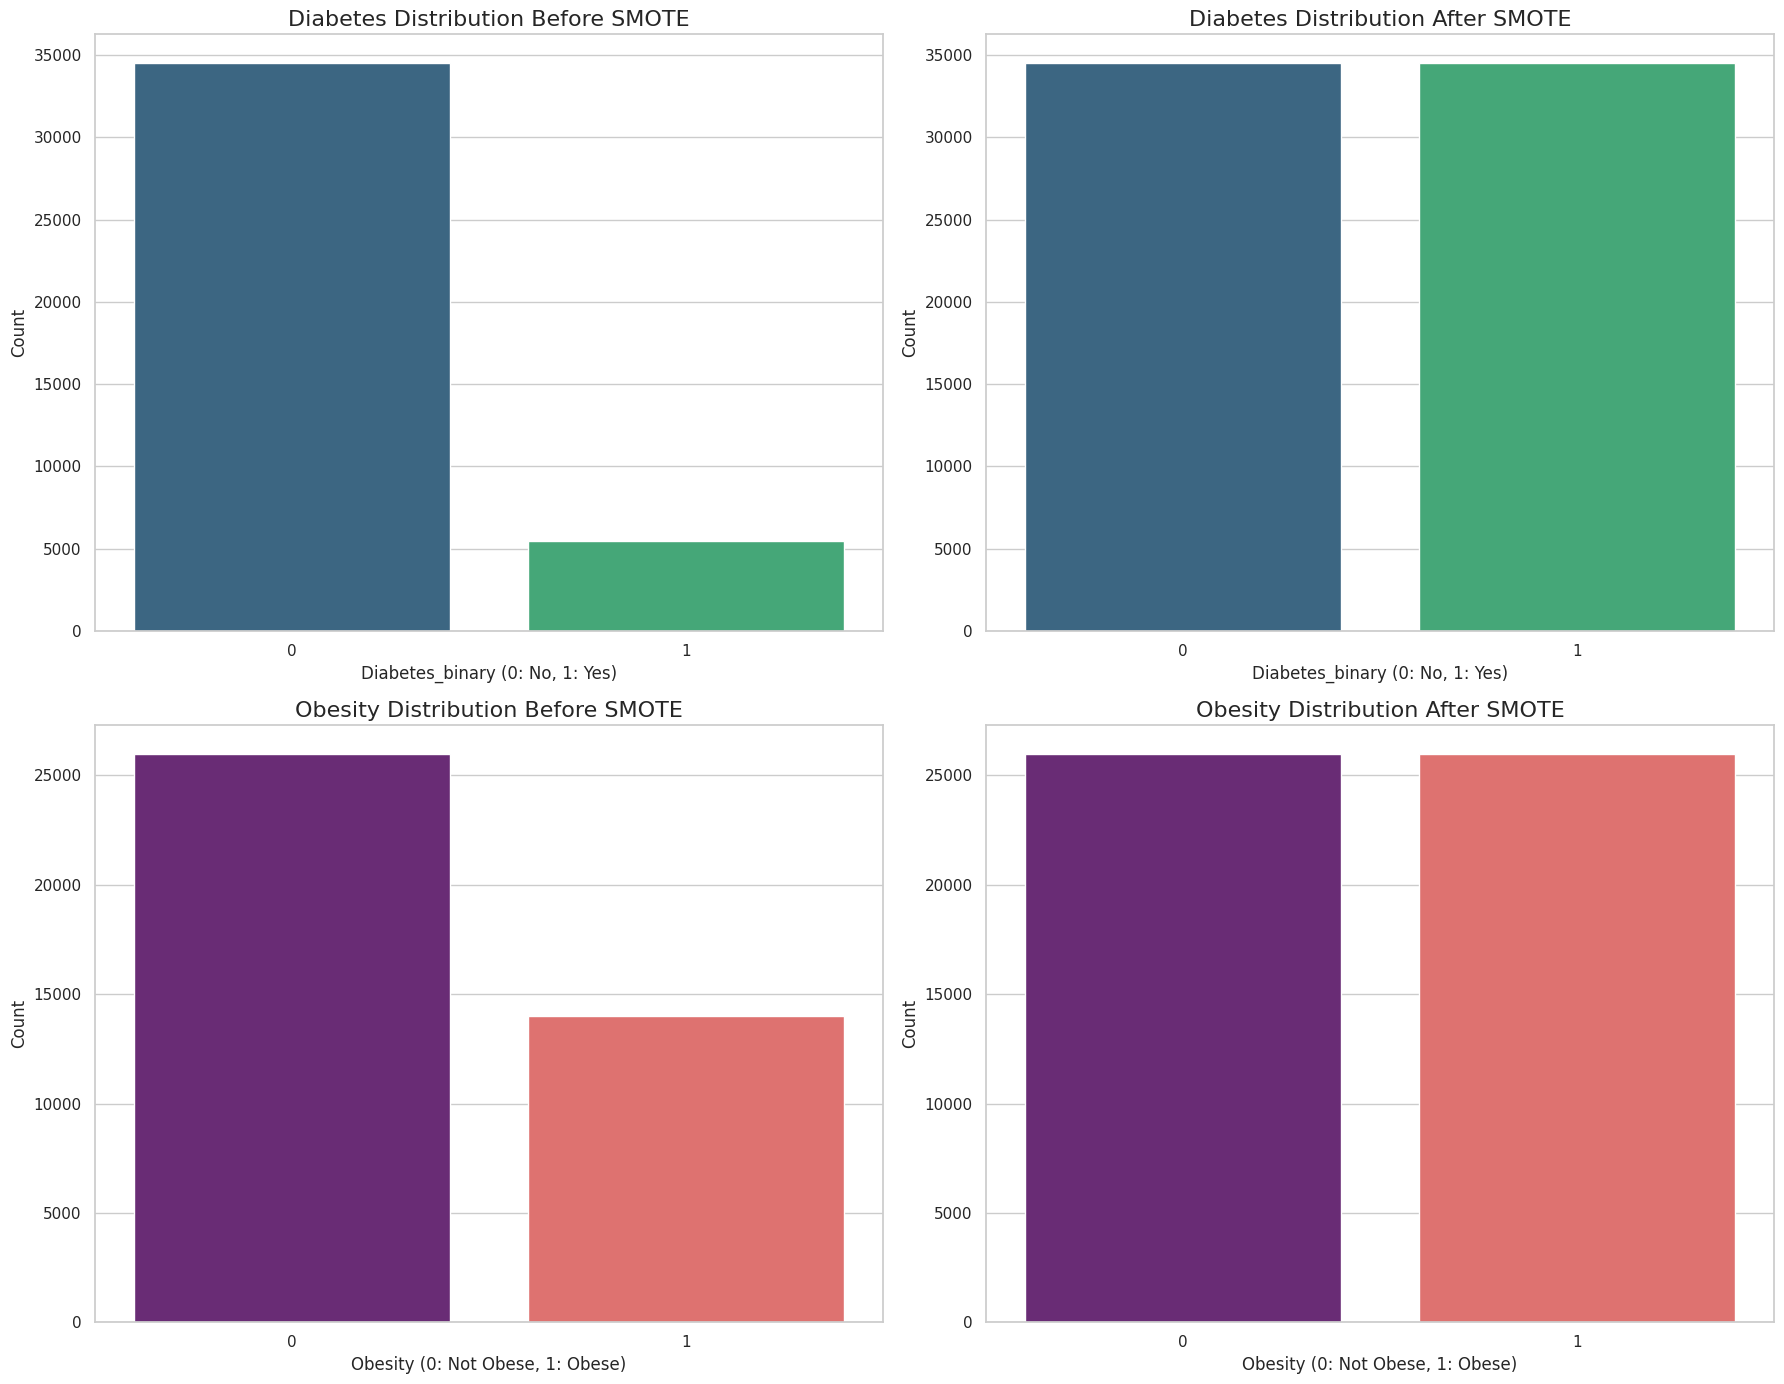

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Diabetes Before SMOTE
sns.countplot(x=df_sample['Diabetes_binary'], ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Diabetes Distribution Before SMOTE', fontsize=16)
axes[0, 0].set_xlabel('Diabetes_binary (0: No, 1: Yes)', fontsize=12)
axes[0, 0].set_ylabel('Count', fontsize=12)

# Diabetes After SMOTE
sns.countplot(x=y_res_d, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Diabetes Distribution After SMOTE', fontsize=16)
axes[0, 1].set_xlabel('Diabetes_binary (0: No, 1: Yes)', fontsize=12)
axes[0, 1].set_ylabel('Count', fontsize=12)

# Obesity Before SMOTE
sns.countplot(x=df_sample['Obesity'], ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Obesity Distribution Before SMOTE', fontsize=16)
axes[1, 0].set_xlabel('Obesity (0: Not Obese, 1: Obese)', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)

# Obesity After SMOTE
sns.countplot(x=y_res_o, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Obesity Distribution After SMOTE', fontsize=16)
axes[1, 1].set_xlabel('Obesity (0: Not Obese, 1: Obese)', fontsize=12)
axes[1, 1].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

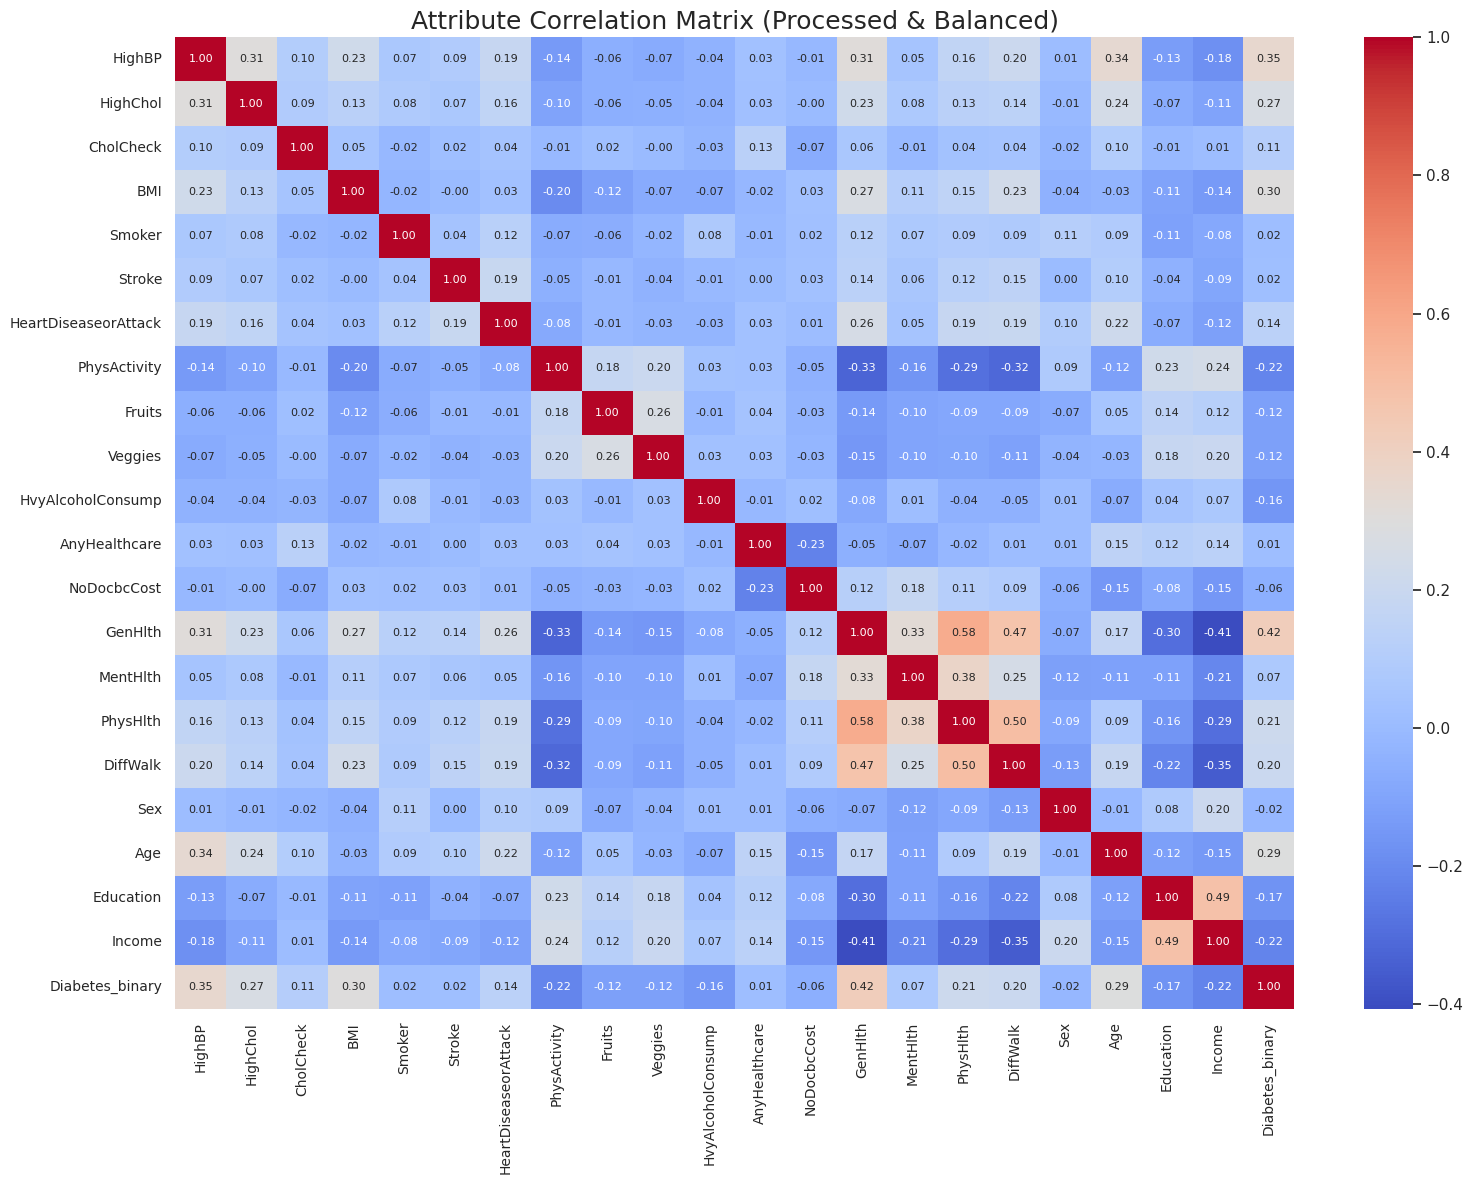

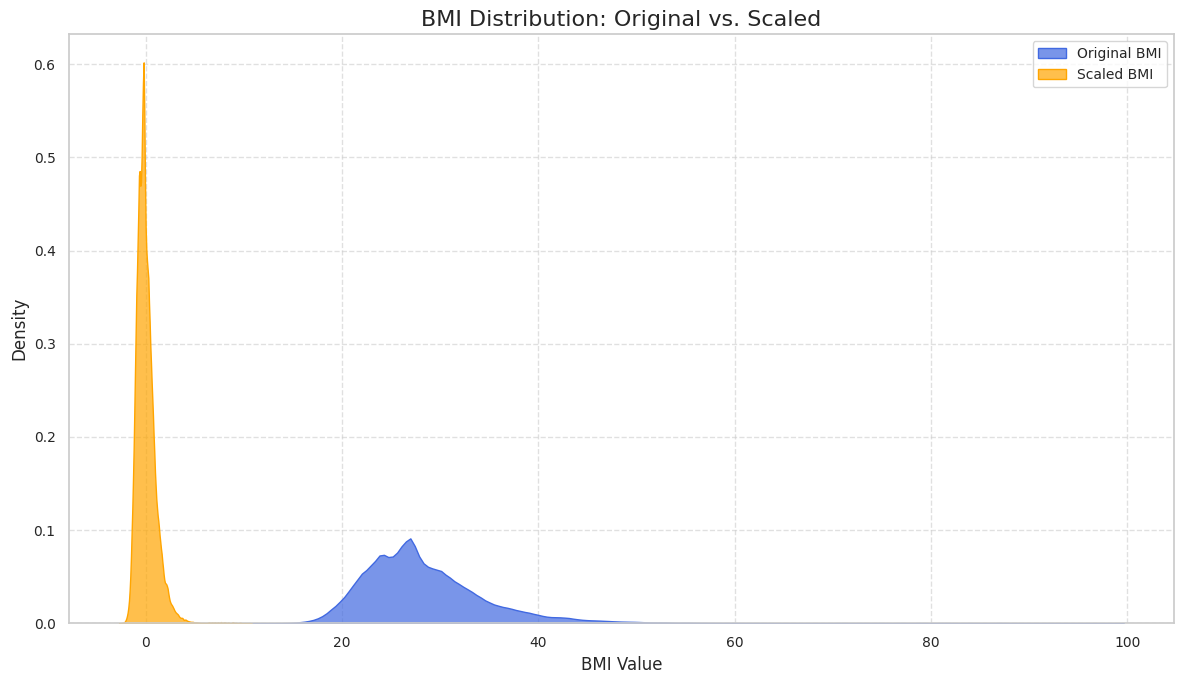

In [24]:
# 5.1 Correlation Heatmap (Balanced & Scaled Data)
# Create df_balanced_d from X_res_d and y_res_d
df_balanced_d = pd.concat([X_res_d, y_res_d], axis=1)

plt.figure(figsize=(16, 12))
sns.heatmap(df_balanced_d.corr(), annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size": 8})
plt.title('Attribute Correlation Matrix (Processed & Balanced)', fontsize=18)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

# 5.2 Scaled Distribution Comparison
plt.figure(figsize=(12, 7))
sns.kdeplot(df_master['BMI'], label='Original BMI', fill=True, color='royalblue', alpha=0.7)
sns.kdeplot(df_preprocessed['BMI'], label='Scaled BMI', fill=True, color='orange', alpha=0.7)
plt.title('BMI Distribution: Original vs. Scaled', fontsize=16)
plt.xlabel('BMI Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [25]:
# Split Data
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_res_d, y_res_d, test_size=0.2, random_state=42)
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(X_res_o, y_res_o, test_size=0.2, random_state=42)

# Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=12),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
}

# Training and Evaluation for Diabetes
diabetes_results = []
trained_diabetes_models = {}

print("Evaluating Models for Diabetes Prediction...")
for name, model in models.items():
    model.fit(X_train_d, y_train_d)
    y_pred = model.predict(X_test_d)
    trained_diabetes_models[name] = model
    diabetes_results.append({
        "Algorithm": name,
        "Accuracy": accuracy_score(y_test_d, y_pred),
        "Precision": precision_score(y_test_d, y_pred),
        "Recall": recall_score(y_test_d, y_pred),
        "F1-Score": f1_score(y_test_d, y_pred)
    })

# Training and Evaluation for Obesity (Using Random Forest as the champion model for simplicity)
print("Training Champion Model for Obesity Prediction...")
rf_obesity = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
rf_obesity.fit(X_train_o, y_train_o)

# Display Results Table
diabetes_results_df = pd.DataFrame(diabetes_results)
print("\n--- Diabetes Prediction Model Performance Table ---")
display(diabetes_results_df.sort_values(by='Accuracy', ascending=False))

Evaluating Models for Diabetes Prediction...
Training Champion Model for Obesity Prediction...

--- Diabetes Prediction Model Performance Table ---


,Algorithm,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.855322,0.824074,0.906860,0.863487
1,Decision Tree,0.838233,0.813344,0.881745,0.846164
0,Logistic Regression,0.754164,0.742830,0.784300,0.763002


In [26]:
def assess_health_risk(input_data, d_model, o_model, scaler, feature_names):
    # Convert input to DataFrame
    input_df = pd.DataFrame([input_data])

    # Ensure all required features are present and in correct order
    for col in feature_names:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[feature_names]

    # Apply Scaling
    input_df[numerical_cols] = scaler.transform(input_df[numerical_cols])

    # Predict Probabilities
    prob_diabetes = d_model.predict_proba(input_df)[0][1] * 100
    prob_obesity = o_model.predict_proba(input_df)[0][1] * 100

    # Calculate Joint Probability (Risk of Both)
    # Using a simplified conditional probability approach: P(A and B)
    prob_both = (prob_diabetes / 100) * (prob_obesity / 100) * 100

    # Format Result Table
    results = pd.DataFrame({
        "Condition": ["Diabetes Risk", "Obesity Risk", "Combined Risk (Both)"],
        "Probability Percentage": [f"{prob_diabetes:.2f}%", f"{prob_obesity:.2f}%", f"{prob_both:.2f}%"],
        "Risk Level": [
            "High" if prob_diabetes > 70 else "Moderate" if prob_diabetes > 30 else "Low",
            "High" if prob_obesity > 70 else "Moderate" if prob_obesity > 30 else "Low",
            "High" if prob_both > 50 else "Moderate" if prob_both > 20 else "Low"
        ]
    })

    return results

# EXAMPLE USER INPUT
# Users can modify these values to see different risk profiles
user_clinical_data = {
    'HighBP': 1, 'HighChol': 1, 'CholCheck': 1, 'BMI': 34, 'Smoker': 1,
    'Stroke': 0, 'HeartDiseaseorAttack': 1, 'PhysActivity': 0, 'Fruits': 0,
    'Veggies': 1, 'HvyAlcoholConsump': 0, 'AnyHealthcare': 1, 'NoDocbcCost': 0,
    'GenHlth': 4, 'MentHlth': 10, 'PhysHlth': 15, 'DiffWalk': 1, 'Sex': 1,
    'Age': 11, 'Education': 4, 'Income': 5
}

# Run Assessment
print("--- INDIVIDUAL HEALTH RISK ASSESSMENT REPORT ---")
risk_report = assess_health_risk(
    user_clinical_data,
    trained_diabetes_models['Random Forest'],
    rf_obesity,
    scaler,
    X_prep.columns.tolist()
)
display(risk_report)

--- INDIVIDUAL HEALTH RISK ASSESSMENT REPORT ---


,Condition,Probability Percentage,Risk Level
0,Diabetes Risk,87.16%,High
1,Obesity Risk,98.60%,High
2,Combined Risk (Both),85.94%,High


Evaluating Models for Diabetes Prediction...


COMPLETE MODEL EVALUATION TABLE



,Algorithm,Accuracy,Precision,Recall,F1-Score,ROC-AUC,MAE,RMSE,MAPE (%),R² Score
4,Extra Trees,0.9073,0.8879,0.9343,0.9105,0.9720,0.0927,0.3044,2.680636e+16,0.6292
3,Gradient Boosting,0.8708,0.8649,0.8817,0.8732,0.9511,0.1292,0.3594,3.130670e+16,0.4832
2,Random Forest,0.8553,0.8241,0.9069,0.8635,0.9349,0.1447,0.3804,4.399244e+16,0.4212
1,Decision Tree,0.8395,0.8150,0.8823,0.8473,0.9185,0.1605,0.4006,4.552516e+16,0.3581
5,KNN,0.8302,0.7628,0.9628,0.8512,0.9148,0.1698,0.4121,6.802686e+16,0.3207
0,Logistic Regression,0.7542,0.7428,0.7843,0.7630,0.8313,0.2458,0.4958,6.170029e+16,0.0166
6,Naive Bayes,0.7350,0.7012,0.8274,0.7591,0.7945,0.2650,0.5148,8.012559e+16,-0.0602



Best Model: Extra Trees


<Figure size 600x500 with 0 Axes>

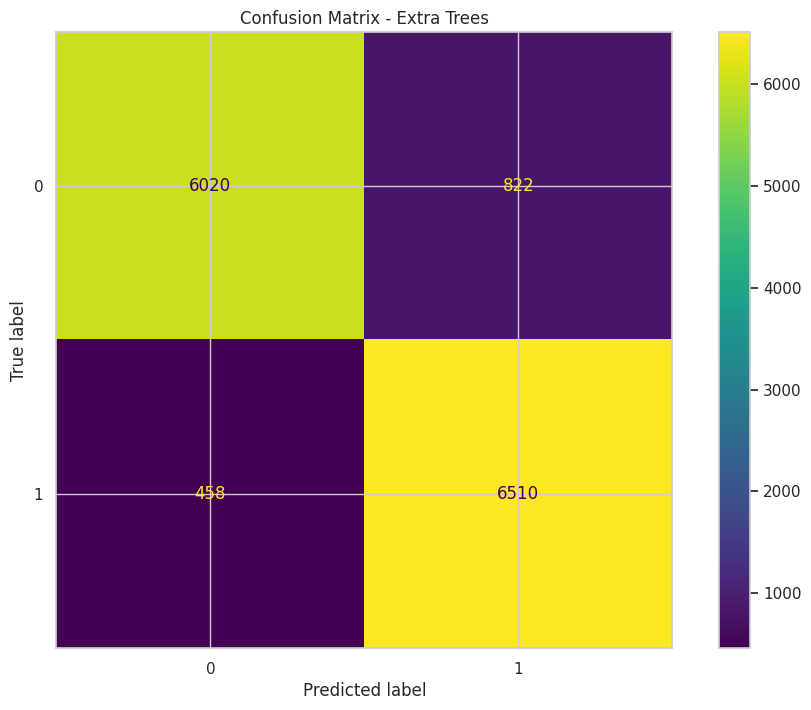

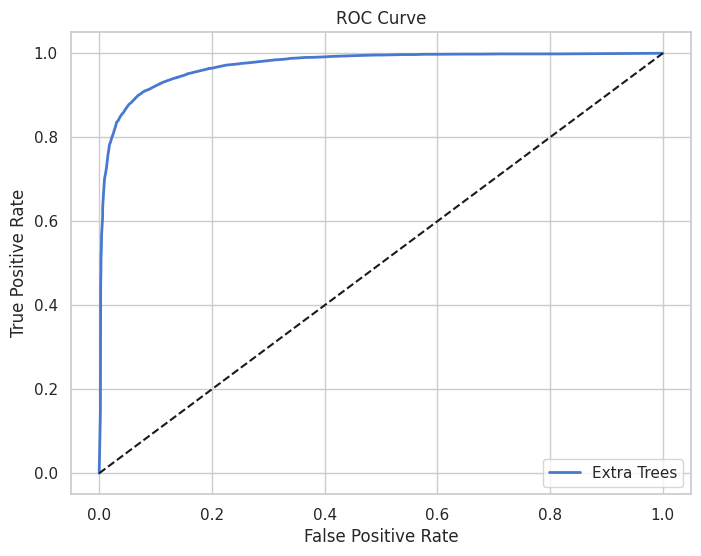

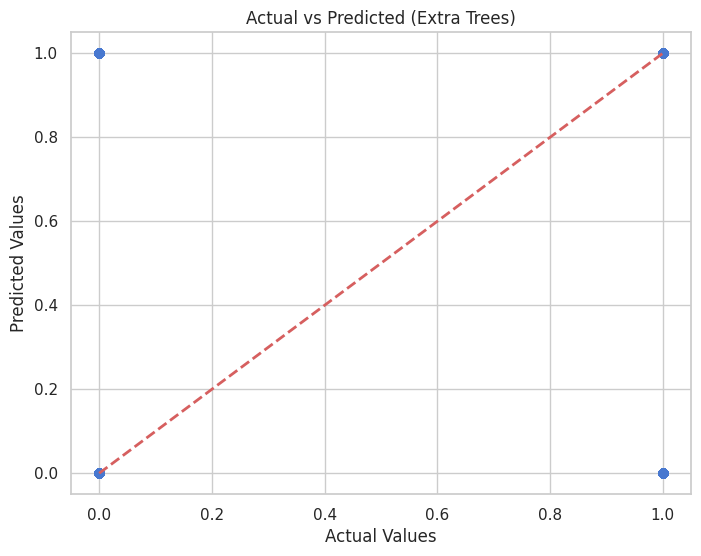

In [27]:
# ==========================================================
# COMPLETE MODEL EVALUATION FOR DIABETES PREDICTION
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# ==========================================================
# SPLIT DATA
# ==========================================================

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_res_d,
    y_res_d,
    test_size=0.2,
    random_state=42
)

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_res_o,
    y_res_o,
    test_size=0.2,
    random_state=42
)

# ==========================================================
# MODELS
# ==========================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB()
}

# ==========================================================
# MODEL TRAINING & EVALUATION
# ==========================================================

diabetes_results = []
trained_diabetes_models = {}

print("Evaluating Models for Diabetes Prediction...\n")

for name, model in models.items():

    # Train Model
    model.fit(X_train_d, y_train_d)

    # Predictions
    y_pred = model.predict(X_test_d)

    trained_diabetes_models[name] = model

    # ROC-AUC Score
    try:
        y_prob = model.predict_proba(X_test_d)[:, 1]
        roc_auc = roc_auc_score(y_test_d, y_prob)
    except:
        roc_auc = np.nan

    # Store Metrics
    diabetes_results.append({
        "Algorithm": name,
        "Accuracy": round(
            accuracy_score(y_test_d, y_pred), 4
        ),
        "Precision": round(
            precision_score(
                y_test_d,
                y_pred,
                zero_division=0
            ),
            4
        ),
        "Recall": round(
            recall_score(
                y_test_d,
                y_pred,
                zero_division=0
            ),
            4
        ),
        "F1-Score": round(
            f1_score(
                y_test_d,
                y_pred,
                zero_division=0
            ),
            4
        ),
        "ROC-AUC": round(
            roc_auc,
            4
        ),
        "MAE": round(
            mean_absolute_error(
                y_test_d,
                y_pred
            ),
            4
        ),
        "RMSE": round(
            np.sqrt(
                mean_squared_error(
                    y_test_d,
                    y_pred
                )
            ),
            4
        ),
        "MAPE (%)": round(
            mean_absolute_percentage_error(
                y_test_d,
                y_pred
            ) * 100,
            4
        ),
        "R² Score": round(
            r2_score(
                y_test_d,
                y_pred
            ),
            4
        )
    })

# ==========================================================
# PERFORMANCE TABLE
# ==========================================================

diabetes_results_df = pd.DataFrame(
    diabetes_results
)

print("\n=================================================")
print("COMPLETE MODEL EVALUATION TABLE")
print("=================================================\n")

display(
    diabetes_results_df.sort_values(
        by="Accuracy",
        ascending=False
    )
)

# ==========================================================
# BEST MODEL
# ==========================================================

best_model_name = diabetes_results_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]["Algorithm"]

best_model = trained_diabetes_models[
    best_model_name
]

print(f"\nBest Model: {best_model_name}")

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

y_pred_best = best_model.predict(
    X_test_d
)

cm = confusion_matrix(
    y_test_d,
    y_pred_best
)

plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.show()

# ==========================================================
# ROC CURVE
# ==========================================================

if hasattr(best_model, "predict_proba"):

    y_prob = best_model.predict_proba(
        X_test_d
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test_d,
        y_prob
    )

    plt.figure(figsize=(8,6))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{best_model_name}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        'k--'
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)

    plt.show()

# ==========================================================
# ACTUAL VS PREDICTED
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_d,
    y_pred_best,
    alpha=0.6
)

plt.plot(
    [y_test_d.min(), y_test_d.max()],
    [y_test_d.min(), y_test_d.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title(
    f"Actual vs Predicted ({best_model_name})"
)

plt.grid(True)

plt.show()

In [28]:

def assess_health_risk(input_data, d_model, o_model, scaler, feature_names):

    input_df = pd.DataFrame([input_data])

    for col in feature_names:
        if col not in input_df.columns:
            input_df[col] = 0

    input_df = input_df[feature_names]

    input_df[numerical_cols] = scaler.transform(
        input_df[numerical_cols]
    )

    prob_diabetes = d_model.predict_proba(input_df)[0][1] * 100

    prob_obesity = o_model.predict_proba(input_df)[0][1] * 100

    prob_both = (
        (prob_diabetes / 100)
        * (prob_obesity / 100)
        * 100
    )

    results = pd.DataFrame({
        "Condition": [
            "Diabetes Risk",
            "Obesity Risk",
            "Combined Risk (Both)"
        ],
        "Probability Percentage": [
            f"{prob_diabetes:.2f}%",
            f"{prob_obesity:.2f}%",
            f"{prob_both:.2f}%"
        ],
        "Risk Level": [
            "High" if prob_diabetes > 70 else
            "Moderate" if prob_diabetes > 30 else
            "Low",

            "High" if prob_obesity > 70 else
            "Moderate" if prob_obesity > 30 else
            "Low",

            "High" if prob_both > 50 else
            "Moderate" if prob_both > 20 else
            "Low"
        ]
    })

    return results

In [29]:
# ==========================================================
# FINAL TEXT REPORT
# ==========================================================

print("\n" + "="*60)
print("      INDIVIDUAL HEALTH RISK ASSESSMENT REPORT")
print("="*60)

diabetes_risk = float(
    risk_report.loc[
        risk_report["Condition"] == "Diabetes Risk",
        "Probability Percentage"
    ].iloc[0].replace("%", "")
)

obesity_risk = float(
    risk_report.loc[
        risk_report["Condition"] == "Obesity Risk",
        "Probability Percentage"
    ].iloc[0].replace("%", "")
)

combined_risk = float(
    risk_report.loc[
        risk_report["Condition"] == "Combined Risk (Both)",
        "Probability Percentage"
    ].iloc[0].replace("%", "")
)

print(f"\nDiabetes Risk : {diabetes_risk:.2f}%")
print(f"Obesity Risk  : {obesity_risk:.2f}%")
print(f"Combined Risk : {combined_risk:.2f}%")

print("\n" + "-"*60)

# ==========================================================
# HEALTH INTERPRETATION
# ==========================================================

if diabetes_risk >= 70:
    print("Diabetes Assessment : HIGH RISK")
elif diabetes_risk >= 30:
    print("Diabetes Assessment : MODERATE RISK")
else:
    print("Diabetes Assessment : LOW RISK")

if obesity_risk >= 70:
    print("Obesity Assessment  : HIGH RISK")
elif obesity_risk >= 30:
    print("Obesity Assessment  : MODERATE RISK")
else:
    print("Obesity Assessment  : LOW RISK")

if combined_risk >= 50:
    print("Overall Health Risk : HIGH")
elif combined_risk >= 20:
    print("Overall Health Risk : MODERATE")
else:
    print("Overall Health Risk : LOW")

print("\n" + "-"*60)

# ==========================================================
# RECOMMENDATIONS
# ==========================================================

recommendations = []

if user_clinical_data["BMI"] >= 30:
    recommendations.append(
        "Reduce body weight through diet and regular exercise."
    )

if user_clinical_data["HighBP"] == 1:
    recommendations.append(
        "Monitor blood pressure regularly."
    )

if user_clinical_data["HighChol"] == 1:
    recommendations.append(
        "Follow a cholesterol-controlled diet."
    )

if user_clinical_data["Smoker"] == 1:
    recommendations.append(
        "Quit smoking to reduce cardiovascular risk."
    )

if user_clinical_data["PhysActivity"] == 0:
    recommendations.append(
        "Increase physical activity to at least 150 minutes per week."
    )

if user_clinical_data["HeartDiseaseorAttack"] == 1:
    recommendations.append(
        "Schedule regular cardiovascular health checkups."
    )

print("PERSONALIZED RECOMMENDATIONS:")

for i, rec in enumerate(recommendations, start=1):
    print(f"{i}. {rec}")

print("\n" + "="*60)
print("Prediction Generated Successfully")
print("="*60)


      INDIVIDUAL HEALTH RISK ASSESSMENT REPORT

Diabetes Risk : 87.16%
Obesity Risk  : 98.60%
Combined Risk : 85.94%

------------------------------------------------------------
Diabetes Assessment : HIGH RISK
Obesity Assessment  : HIGH RISK
Overall Health Risk : HIGH

------------------------------------------------------------
PERSONALIZED RECOMMENDATIONS:
1. Reduce body weight through diet and regular exercise.
2. Monitor blood pressure regularly.
3. Follow a cholesterol-controlled diet.
4. Quit smoking to reduce cardiovascular risk.
5. Increase physical activity to at least 150 minutes per week.
6. Schedule regular cardiovascular health checkups.

Prediction Generated Successfully


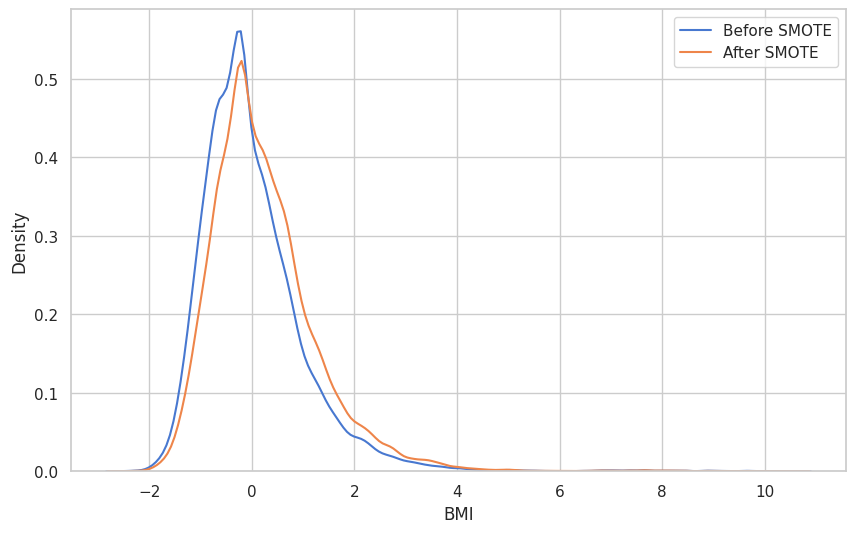

In [30]:
plt.figure(figsize=(10,6))
sns.kdeplot(df_sample['BMI'], label='Before SMOTE')
sns.kdeplot(X_res_d['BMI'], label='After SMOTE')
plt.legend()